# Feature Engineering and Gold Layer

This notebook demonstrates the feature engineering stage of the insurance fraud analytics project.

## Objectives
- Review feature signal discovered from Silver-layer data
- Engineer model-ready features for IEEE-CIS and Porto Seguro
- Validate engineered columns
- Preview Gold-layer datasets for downstream modeling

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [0]:
txn = spark.table("default.train_transaction")
porto = spark.table("default.train")

In [0]:
porto.show()

+---+------+---------+-------------+---------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+---------+---------+-------------+-------------+-------------+---------+---------+-------------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+---------+-------------------+-------------------+-------------------+------------------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+--------------+--------------+--------------+--------------+--------------+--------------+
| id|target|ps_ind_01|ps_ind_02_cat|ps_ind_03|ps_ind_04_cat|ps_ind_05_cat|ps_ind_06_bin|ps_ind_07_bin|ps_ind_08_bin|ps_ind_09_bin|ps_ind_10_bin|ps_ind_11_bin|ps_ind_12_bin|ps_ind_13_bin|ps_ind_14|ps_ind_15|ps_ind_16_bin|ps_i

In [0]:
df_txn = txn.sample(fraction=0.1, seed=42).toPandas()
print("IEEE sample shape :", df_txn.shape)


IEEE sample shape : (58905, 394)


In [0]:
df_porto = porto.sample(fraction=0.1, seed=42).toPandas()
print("Porto sample shape:", df_porto.shape)

Porto sample shape: (59660, 59)


## Why sampled data is used in this notebook

The full Gold-layer pipeline was implemented and tested locally in reusable Python modules.

This notebook uses sampled data to:
- keep execution lightweight in Databricks
- explain feature engineering interactively
- validate feature behavior visually

## Selected feature ideas

### IEEE-CIS
The selected IEEE-CIS features were based on:
-  EDA findings
- feature usefulness analysis
- fraud-oriented behavior patterns

Chosen feature groups:
- transaction amount transformation
- time-based behavior
- frequency encoding of key categoricals
- simple transaction count behavior
- amount deviation from grouped average

### Porto Seguro
The selected Porto Seguro features were based on:
- target-separation analysis from Silver-layer data
- interaction between vehicle and driver attributes
- aggregated binary risk behavior
- simple business-style risk flagging

In [0]:
#Add IEEE feature functions

def add_transaction_amount_log(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "TransactionAmt" in df.columns:
        df["TransactionAmt_log1p"] = np.log1p(df["TransactionAmt"])
    return df


def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "TransactionDT" in df.columns:
        df["hour_of_day"] = ((df["TransactionDT"] // 3600) % 24).astype(int)
        df["is_night"] = ((df["hour_of_day"] == 23) | (df["hour_of_day"].between(0, 5))).astype(int)
    return df


def add_frequency_encoding(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    df = df.copy()
    for col in columns:
        if col in df.columns:
            freq_map = df[col].value_counts(dropna=False).to_dict()
            df[f"{col}_freq"] = df[col].map(freq_map)
    return df


def add_card_transaction_count(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "card1" in df.columns:
        df["card1_txn_count"] = df.groupby("card1")["card1"].transform("count")
    return df


def add_card4_amount_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "card4" in df.columns and "TransactionAmt" in df.columns:
        df["card4_amt_mean"] = df.groupby("card4")["TransactionAmt"].transform("mean")
        df["amt_deviation_card4"] = df["TransactionAmt"] - df["card4_amt_mean"]
    return df


def build_ieee_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df = add_transaction_amount_log(df)
    df = add_time_features(df)
    df = add_frequency_encoding(df, ["ProductCD", "card4", "card6"])
    df = add_card_transaction_count(df)
    df = add_card4_amount_features(df)
    return df

In [0]:
#Add Porto feature functions code

def add_vehicle_driver_interaction(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "ps_car_13" in df.columns and "ps_ind_03" in df.columns:
        df["vehicle_driver_interaction"] = df["ps_car_13"] * df["ps_ind_03"]
    return df


def add_binary_risk_count(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    binary_cols = [
        "ps_ind_06_bin",
        "ps_ind_07_bin",
        "ps_ind_08_bin",
        "ps_ind_09_bin",
        "ps_ind_16_bin",
        "ps_ind_17_bin",
        "ps_ind_18_bin"
    ]

    existing_binary_cols = [col for col in binary_cols if col in df.columns]
    if existing_binary_cols:
        df["binary_risk_count"] = df[existing_binary_cols].sum(axis=1)

    return df


def add_high_risk_flag(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    high_risk_conditions = []

    if "ps_ind_03" in df.columns:
        high_risk_conditions.append(df["ps_ind_03"] > df["ps_ind_03"].median())

    if "ps_car_13" in df.columns:
        high_risk_conditions.append(df["ps_car_13"] > df["ps_car_13"].median())

    if "binary_risk_count" in df.columns:
        high_risk_conditions.append(df["binary_risk_count"] >= 2)

    if high_risk_conditions:
        combined_condition = np.column_stack(high_risk_conditions).sum(axis=1) >= 2
        df["high_risk_flag"] = combined_condition.astype(int)

    return df


def build_porto_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df = add_vehicle_driver_interaction(df)
    df = add_binary_risk_count(df)
    df = add_high_risk_flag(df)
    return df

In [0]:
#Build engineered features

df_txn_feat = build_ieee_features(df_txn)
df_porto_feat = build_porto_features(df_porto)

print("IEEE feature shape :", df_txn_feat.shape)
print("Porto feature shape:", df_porto_feat.shape)

IEEE feature shape : (58905, 403)
Porto feature shape: (59660, 62)


## Feature explanations

### IEEE-CIS

**TransactionAmt_log1p**  
- What: log-transformed transaction amount  
- Why: raw transaction amount is right-skewed, so log transform stabilizes the distribution  
- How: `np.log1p(TransactionAmt)`

**hour_of_day**  
- What: approximate hour extracted from `TransactionDT`  
- Why: transaction timing may capture behavioral patterns linked to fraud  
- How: `(TransactionDT // 3600) % 24`

**is_night**  
- What: binary flag for late-night transactions  
- Why: suspicious activity may cluster during unusual hours  
- How: 1 if hour is between 11 PM and 5 AM

**ProductCD_freq / card4_freq / card6_freq**  
- What: frequency encoding of key categorical variables  
- Why: converts categorical fields into numeric signals while preserving prevalence information  
- How: map category counts back to each row

**card1_txn_count**  
- What: count of transactions sharing the same `card1`  
- Why: repeated behavior can be informative in fraud detection  
- How: group by `card1` and count rows

**card4_amt_mean / amt_deviation_card4**  
- What: grouped average amount and deviation from that average  
- Why: unusual amount relative to peer group may be suspicious  
- How: group by `card4` and compare each amount with the group mean

### Porto Seguro

**vehicle_driver_interaction**  
- What: interaction between `ps_car_13` and `ps_ind_03`  
- Why: combined vehicle and driver characteristics may capture stronger risk than either alone  
- How: multiplication of the two columns

**binary_risk_count**  
- What: count of selected binary risk indicators  
- Why: multiple risk signals together may better represent claim risk  
- How: row-wise sum across selected binary columns

**high_risk_flag**  
- What: simple rule-based high-risk indicator  
- Why: supports interpretable risk grouping and later business decisioning  
- How: flag rows meeting at least two median-based risk conditions

In [0]:
#engineered column

ieee_new_cols = [
    "TransactionAmt_log1p",
    "hour_of_day",
    "is_night",
    "ProductCD_freq",
    "card4_freq",
    "card6_freq",
    "card1_txn_count",
    "card4_amt_mean",
    "amt_deviation_card4"
]

porto_new_cols = [
    "vehicle_driver_interaction",
    "binary_risk_count",
    "high_risk_flag"
]

display(df_txn_feat[ieee_new_cols].head())
display(df_porto_feat[porto_new_cols].head())

TransactionAmt_log1p,hour_of_day,is_night,ProductCD_freq,card4_freq,card6_freq,card1_txn_count,card4_amt_mean,amt_deviation_card4
6.878274973659629,22,0,43897,38411,43886,18,132.91719379865143,837.0328062013486
4.532599493153256,22,0,43897,38411,43886,6,132.91719379865143,-40.917193798651425
4.532599493153256,22,0,43897,38411,43886,42,132.91719379865143,-40.917193798651425
2.791717102674781,22,0,6692,18782,43886,471,131.30353705675645,-115.99453705675646
3.912023005428146,22,0,43897,38411,43886,239,132.91719379865143,-83.91719379865143


vehicle_driver_interaction,binary_risk_count,high_risk_flag
4.418394589,2,1
5.7742714467,2,1
0.0,2,0
1.9190487053999998,2,0
0.7637040012999999,2,0


In [0]:
#Validate nulls and infinities in engineered features

def validate_new_features(df: pd.DataFrame, feature_cols: list[str], name: str):
    null_total = df[feature_cols].isnull().sum().sum()
    numeric_part = df[feature_cols].select_dtypes(include=[np.number])
    inf_total = np.isinf(numeric_part).sum().sum()
    
    print(f"{name}")
    print(f"  Null values in engineered features: {int(null_total)}")
    print(f"  Infinite values in engineered features: {int(inf_total)}")

validate_new_features(df_txn_feat, ieee_new_cols, "IEEE engineered features")
validate_new_features(df_porto_feat, porto_new_cols, "Porto engineered features")

IEEE engineered features
  Null values in engineered features: 282
  Infinite values in engineered features: 0
Porto engineered features
  Null values in engineered features: 0
  Infinite values in engineered features: 0


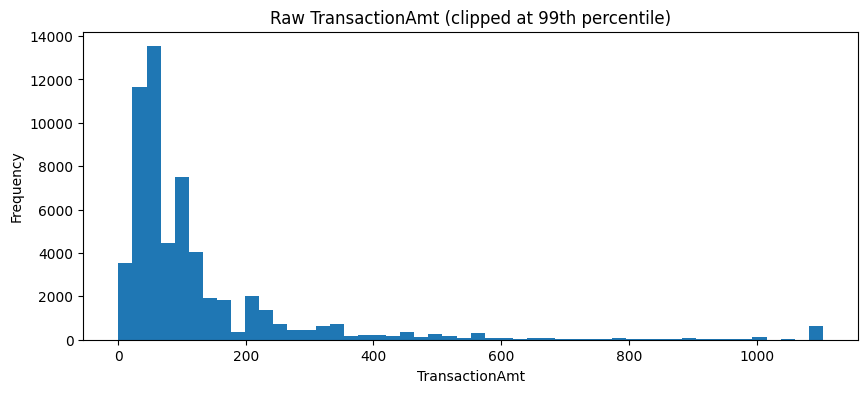

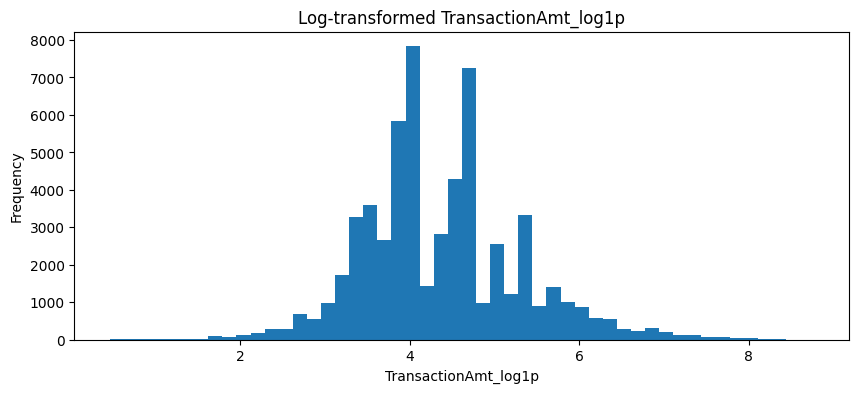

In [0]:
#Compare raw vs transformed amount distribution

plt.figure(figsize=(10, 4))
df_txn["TransactionAmt"].dropna().clip(
    upper=df_txn["TransactionAmt"].quantile(0.99)
).plot(kind="hist", bins=50)
plt.title("Raw TransactionAmt (clipped at 99th percentile)")
plt.xlabel("TransactionAmt")
plt.show()

plt.figure(figsize=(10, 4))
df_txn_feat["TransactionAmt_log1p"].dropna().plot(kind="hist", bins=50)
plt.title("Log-transformed TransactionAmt_log1p")
plt.xlabel("TransactionAmt_log1p")
plt.show()

In [0]:
print(df_txn_feat[ieee_new_cols].isnull().sum())

TransactionAmt_log1p      0
hour_of_day               0
is_night                  0
ProductCD_freq            0
card4_freq                0
card6_freq                0
card1_txn_count           0
card4_amt_mean          141
amt_deviation_card4     141
dtype: int64


In [0]:
df_txn_feat[ieee_new_cols] = df_txn_feat[ieee_new_cols].fillna(0)

In [0]:
print(df_txn_feat[ieee_new_cols].isnull().sum())

TransactionAmt_log1p    0
hour_of_day             0
is_night                0
ProductCD_freq          0
card4_freq              0
card6_freq              0
card1_txn_count         0
card4_amt_mean          0
amt_deviation_card4     0
dtype: int64


In [0]:
validate_new_features(df_txn_feat, ieee_new_cols, "IEEE engineered features")
validate_new_features(df_porto_feat, porto_new_cols, "Porto engineered features")

IEEE engineered features
  Null values in engineered features: 0
  Infinite values in engineered features: 0
Porto engineered features
  Null values in engineered features: 0
  Infinite values in engineered features: 0


That means feature set is now clean and model-ready.
feature creation worked -> validation worked ->meeting Gold-pipeline expectations


In [0]:
#Inspect simple target relationships for new features

print("IEEE engineered feature means by fraud target")
print(
    df_txn_feat.groupby("isFraud")[[
        "TransactionAmt_log1p",
        "hour_of_day",
        "is_night",
        "ProductCD_freq",
        "card4_freq",
        "card6_freq",
        "card1_txn_count",
        "card4_amt_mean",
        "amt_deviation_card4"
    ]].mean()
)

print("\nPorto engineered feature means by target")
print(
    df_porto_feat.groupby("target")[[
        "vehicle_driver_interaction",
        "binary_risk_count",
        "high_risk_flag"
    ]].mean()
)

IEEE engineered feature means by fraud target
         TransactionAmt_log1p  hour_of_day  ...  card4_amt_mean  amt_deviation_card4
isFraud                                     ...                                     
0                    4.384782    13.862582  ...      133.955629            -0.616746
1                    4.437615    13.311459  ...      135.723229            17.174360

[2 rows x 9 columns]

Porto engineered feature means by target
        vehicle_driver_interaction  binary_risk_count  high_risk_flag
target                                                               
0                         3.616223           1.935746        0.685450
1                         4.123207           1.939531        0.755866


## Gold-layer readiness

The engineered feature sets are now ready for Gold-layer creation because:

- key behavioral and interaction-based features were added
- engineered columns were validated for null and infinite values
- transformed numeric fields show improved modeling suitability
- the feature set remains interpretable and aligned with the fraud/risk problem

In [0]:
#preview
print("IEEE total columns after feature engineering:", len(df_txn_feat.columns))
print("Porto total columns after feature engineering:", len(df_porto_feat.columns))

IEEE total columns after feature engineering: 403
Porto total columns after feature engineering: 62



## Conclusion

Completed the feature engineering stage by:

- analyzing which raw variables showed signal against the target
- engineering interpretable fraud and risk features
- validating the engineered columns
- preparing Gold-layer datasets for downstream modeling

The next stage is model development using the Gold feature sets.